In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score, confusion_matrix, f1_score
from keras.models import Sequential, Model
from keras.layers import Input, Dense
from collections import Counter
from sklearn.datasets import make_classification
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline
from matplotlib import pyplot
from numpy import where

# File path
csv_file_path = r"C:\Users\olufe\projects\Journal\dataset\HomeB_unsupervise_sim_combined_data.csv"

# Load the data from the CSV file
data = pd.read_csv(csv_file_path)

# Extract features (X) and target labels (y) from the loaded data
X = data.drop(columns=["Label"])  # Replace "target_column_name" with the actual column name for the target variable
y = data["Label"]  # Replace "target_column_name" with the actual column name for the target variable

# Print the extracted values of X and y
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (35328, 1380)
y shape: (35328,)


In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#X_train, X_test, y_train, y_test = X[:60000], X[60000:], y[:60000], y[60000:]

### Apply SMOTE on the Training Data:
#### Use the SMOTE class from the imbalanced-learn library to oversample the minority class in the training data.

In [4]:
from imblearn.over_sampling import SMOTE

# Create a SMOTE instance
smote = SMOTE(random_state=42)

# Apply SMOTE on the training data
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

In [5]:
# summarize the new class distribution
counter = Counter(y)
print(counter)

Counter({0: 35186, 1: 142})


In [6]:
# summarize the new class distribution
counter = Counter(y_train_resampled)
print(counter)

Counter({0: 28147, 1: 28147})


In [7]:
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.neural_network import MLPClassifier
from imblearn.over_sampling import SMOTE
# Train an MLP Classifier on the resampled data
mlp = MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=1000, random_state=42)
mlp.fit(X_train_resampled, y_train_resampled)

# Predict the target on the testing data
y_pred = mlp.predict(X_test)

# Calculate performance metrics
report = classification_report(y_test, y_pred, target_names=['class_0', 'class_1'])
roc_auc = roc_auc_score(y_test, y_pred)

print("Classification Report:")
print(report)

print("ROC AUC Score:", roc_auc)

#This code uses the resampled data obtained from SMOTE to train an MLP Classifier and then evaluates its performance using various metrics. Note that this example assumes a binary classification problem; if you're dealing with a multi-class problem, you'll need to modify the code accordingly.


Classification Report:
              precision    recall  f1-score   support

     class_0       1.00      0.91      0.95      7039
     class_1       0.02      0.59      0.05        27

    accuracy                           0.90      7066
   macro avg       0.51      0.75      0.50      7066
weighted avg       0.99      0.90      0.95      7066

ROC AUC Score: 0.7492015385182028


In [10]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score, confusion_matrix, f1_score
from keras.models import Sequential, Model
from keras.layers import Input, Dense
from collections import Counter
from sklearn.datasets import make_classification
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline
from matplotlib import pyplot
from numpy import where

# File path
csv_file_path = r"C:\Users\olufe\projects\Journal\dataset\HomeB_unsupervise_real_combined_data.csv"

# Load the data from the CSV file
data = pd.read_csv(csv_file_path)

# Extract features (X) and target labels (y) from the loaded data
X = data.drop(columns=["Label"])  # Replace "target_column_name" with the actual column name for the target variable
y = data["Label"]  # Replace "target_column_name" with the actual column name for the target variable

# Print the extracted values of X and y
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (52560, 1380)
y shape: (52560,)


In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [12]:
# Use the SMOTE class from the imbalanced-learn library to oversample the minority class in the training data
from imblearn.over_sampling import SMOTE

# Create a SMOTE instance
smote = SMOTE(random_state=42)

# Apply SMOTE on the training data
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

In [13]:
#print("Number of features in training data:", X.shape[1])
#print("Number of features in test data:", y.shape[1])

In [14]:
# summarize class distribution
counter = Counter(y)
print(counter)

Counter({0: 43800, 1: 8760})


In [15]:
# summarize class distribution
counter = Counter(y_train_resampled)
print(counter)

Counter({1: 35023, 0: 35023})


In [16]:
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.neural_network import MLPClassifier
from imblearn.over_sampling import SMOTE
# Train an MLP Classifier on the resampled data
mlp = MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=1000, random_state=42)
mlp.fit(X_train_resampled, y_train_resampled)

# Predict the target on the testing data
y_pred = mlp.predict(X_test)

# Calculate performance metrics
report = classification_report(y_test, y_pred, target_names=['class_0', 'class_1'])
roc_auc = roc_auc_score(y_test, y_pred)

print("Classification Report:")
print(report)

print("ROC AUC Score:", roc_auc)


Classification Report:
              precision    recall  f1-score   support

     class_0       0.97      0.95      0.96      8777
     class_1       0.78      0.86      0.82      1735

    accuracy                           0.94     10512
   macro avg       0.88      0.91      0.89     10512
weighted avg       0.94      0.94      0.94     10512

ROC AUC Score: 0.9059310767367816


In [38]:
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt

some_digit = X[0]
some_digit_image = some_digit.reshape(28, 28)
plt.imshow(some_digit_image, cmap=mpl.cm.binary)
plt.axis("off")

save_fig("some_digit_plot")
plt.show()

KeyError: 0

In [37]:
# transform the dataset
oversample = SMOTE()
X, y = oversample.fit_resample(X, y)

In [29]:
# define pipeline
#over = SMOTE(sampling_strategy=0.1)
#under = RandomUnderSampler(sampling_strategy=0.5)
#steps = [('o', over), ('u', under)]
#pipeline = Pipeline(steps=steps)

In [30]:
# transform the dataset
#X, y = pipeline.fit_resample(X, y)

In [31]:
# summarize the new class distribution
counter = Counter(y)
print(counter)

Counter({0: 35186, 1: 35186})


In [11]:
# Separate the target column (if available) from the training data
# Assuming the target column is the last column (change if not the case)
train_target = train_data.iloc[:, -1]
train_data = train_data.iloc[:, :-1]
#X = train_data.iloc[:, -1]
#y = train_data.iloc[:, :-1]


# Check for missing values in both datasets
#print("Number of missing values in training data:", train_data.isnull().sum().sum())
#print("Number of missing values in test data:", test_data.isnull().sum().sum())

# Store the column names for later use
#column_names = train_data.columns

# Convert non-numeric values to numeric using LabelEncoder
#label_encoder = LabelEncoder()
#for column in train_data.columns:
#    if train_data[column].dtype == 'object':
#        train_data[column] = label_encoder.fit_transform(train_data[column])
#        test_data[column] = label_encoder.transform(test_data[column])

# Ensure the test data has the same set of columns as the training data
#extra_columns = set(test_data.columns) - set(column_names)
#if extra_columns:
#    test_data.drop(columns=extra_columns, inplace=True)

# Handle missing values in the test dataset
#test_data = test_data.fillna(0)  # You can use other imputation techniques based on your data

# Normalize the data using MinMaxScaler
#scaler = MinMaxScaler()
#train_data = scaler.fit_transform(train_data)
#test_data = scaler.transform(test_data)

# Convert back to DataFrames for easy evaluation
#train_data = pd.DataFrame(train_data, columns=column_names)
#test_data = pd.DataFrame(test_data, columns=column_names)


In [32]:
# Define the MLP-AE model:
def build_autoencoder(input_dim):
    model = Sequential()
    model.add(Dense(64, activation='relu', input_dim=input_dim))
    model.add(Dense(32, activation='relu'))
    model.add(Dense(64, activation='relu'))
    model.add(Dense(input_dim, activation='sigmoid'))
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

#input_dim = train_data.shape[1]
input_dim = X_train.shape[1]
autoencoder = build_autoencoder(input_dim)

In [33]:
# Split the training data into training and validation sets
#X_train, X_val, y_train, y_val = train_test_split(train_data, train_data, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train, X_train, test_size=0.2, random_state=42)

In [34]:
# Train the MLP-AE model with validation data:
history = autoencoder.fit(X_train, X_train, epochs=100, batch_size=32, validation_data=(X_val, X_val), verbose=0)

In [35]:
# Access training loss values
training_loss = history.history['loss']
validation_loss = history.history['val_loss']


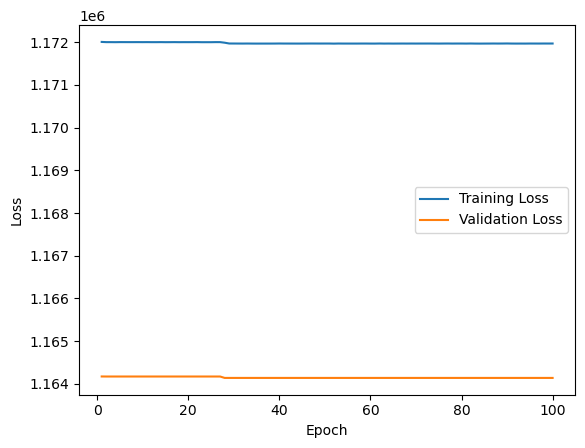

In [36]:
import matplotlib.pyplot as plt

plt.plot(range(1, len(training_loss) + 1), training_loss, label='Training Loss')
plt.plot(range(1, len(validation_loss) + 1), validation_loss, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()


In [17]:
#Use the trained model to make predictions:
train_preds = autoencoder.predict(train_data)
test_preds = autoencoder.predict(test_data)

10/10 [==============================] - 0s 1ms/step


In [37]:
#Evaluate the model performance using the specified metrics:
#def evaluate_performance(y_true, y_pred):
#    accuracy = accuracy_score(y_true, y_pred.round())
#    precision = precision_score(y_true, y_pred.round())
#    recall = recall_score(y_true, y_pred.round())
#    tn, fp, fn, tp = confusion_matrix(y_true, y_pred.round()).ravel()
#    tnr = tn / (tn + fp)
#    fpr = fp / (tn + fp)
#    fnr = fn / (fn + tp)
#    f1 = f1_score(y_true, y_pred.round())
#    auc = roc_auc_score(y_true, y_pred)

#    return accuracy, precision, recall, tnr, fpr, fnr, f1, auc
#######################################################################
# Define function for performance evaluation
def evaluate_performance(y_true, y_pred):
    mse = np.mean(np.square(y_true - y_pred), axis=1)
    # Assuming the threshold is 0.5 for anomaly detection (adjust if needed)
    anomaly_preds = (mse > 0.5).astype(int)
    
    accuracy = accuracy_score(y_true, anomaly_preds)
    precision = precision_score(y_true, anomaly_preds)
    recall = recall_score(y_true, anomaly_preds)
    tn, fp, fn, tp = confusion_matrix(y_true, anomaly_preds).ravel()
    tnr = tn / (tn + fp)
    fpr = fp / (tn + fp)
    fnr = fn / (fn + tp)
    f1 = f1_score(y_true, anomaly_preds)
    auc = roc_auc_score(y_true, mse)
    
    return accuracy, precision, recall, tnr, fpr, fnr, f1, auc

#######################################################################

# Assuming your target column is named 'Label' in the test_data DataFrame
test_target = test_data['Label'] if 'Label' in test_data else None
accuracy, precision, recall, tnr, fpr, fnr, f1, auc = evaluate_performance(test_target, test_preds)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("TNR:", tnr)
print("FPR:", fpr)
print("FNR:", fnr)
print("F1-score:", f1)
print("AUC:", auc)


TypeError: unsupported operand type(s) for -: 'NoneType' and 'float'

In [26]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score, confusion_matrix, f1_score
from keras.models import Sequential, Model
from keras.layers import Input, Dense

# Load the dataset
train_path = "C:/Users/olufe/projects/Journal/dataset/psa_journal_home_A_unsupervise_train.csv"
test_path = "C:/Users/olufe/projects/Journal/dataset/psa_journal_home_A_sim_test.csv"

train_data = pd.read_csv(train_path)
test_data = pd.read_csv(test_path)

# Separate the target column (if available) from the training data
# Assuming the target column is the last column (change if not the case)
train_target = train_data.iloc[:, -1]
train_data = train_data.iloc[:, :-1]

# Check for missing values in both datasets
print("Number of missing values in training data:", train_data.isnull().sum().sum())
print("Number of missing values in test data:", test_data.isnull().sum().sum())

# Store the column names for later use
column_names = train_data.columns

# Convert non-numeric values to numeric using LabelEncoder (if any)
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
for column in train_data.columns:
    if train_data[column].dtype == 'object':
        train_data[column] = label_encoder.fit_transform(train_data[column])
        test_data[column] = label_encoder.transform(test_data[column])

# Ensure the test data has the same set of columns as the training data
extra_columns = set(test_data.columns) - set(column_names)
if extra_columns:
    test_data.drop(columns=extra_columns, inplace=True)

# Handle missing values in the test dataset
test_data = test_data.fillna(0)  # You can use other imputation techniques based on your data

# Normalize the data using MinMaxScaler
scaler = MinMaxScaler()
train_data = scaler.fit_transform(train_data)
test_data = scaler.transform(test_data)

# Define the MLP-AE model:
def build_autoencoder(input_dim):
    model = Sequential()
    model.add(Dense(64, activation='relu', input_dim=input_dim))
    model.add(Dense(32, activation='relu'))
    model.add(Dense(64, activation='relu'))
    model.add(Dense(input_dim, activation='sigmoid'))
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

input_dim = train_data.shape[1]
autoencoder = build_autoencoder(input_dim)

# Define function for performance evaluation
def evaluate_performance(y_true, y_pred):
    accuracy = accuracy_score(y_true, y_pred.round())
    precision = precision_score(y_true, y_pred.round())
    recall = recall_score(y_true, y_pred.round())
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred.round()).ravel()
    tnr = tn / (tn + fp)
    fpr = fp / (tn + fp)
    fnr = fn / (fn + tp)
    f1 = f1_score(y_true, y_pred.round())
    auc = roc_auc_score(y_true, y_pred)
    return accuracy, precision, recall, tnr, fpr, fnr, f1, auc

# Perform k-fold cross-validation and evaluate the model
k = 5
kf = KFold(n_splits=k, shuffle=True, random_state=42)
fold_metrics = []

for train_index, val_index in kf.split(train_data):
    X_train, X_val = train_data[train_index], train_data[val_index]
    
    # Assuming your target column is named 'target' in the train_data DataFrame
    y_train, y_val = train_target[train_index], train_target[val_index]
    
    # Assuming your target column is named 'Label' in the train_data DataFrame
    #y_train, y_val = train_Label[train_index], train_Label[val_index]
    
    # Train the MLP-AE model with validation data:
    history = autoencoder.fit(X_train, X_train, epochs=100, batch_size=32, validation_data=(X_val, X_val), verbose=0)
    
    # Use the trained model to make predictions on the validation data
    val_preds = autoencoder.predict(X_val)
    
    # Evaluate performance on the validation set
    fold_metrics.append(evaluate_performance(y_val, val_preds))

# Calculate the mean and standard deviation of metrics across folds
mean_metrics = np.mean(fold_metrics, axis=0)
std_metrics = np.std(fold_metrics, axis=0)

print("Mean Metrics:")
print("Accuracy:", mean_metrics[0])
print("Precision:", mean_metrics[1])
print("Recall:", mean_metrics[2])
print("TNR:", mean_metrics[3])
print("FPR:", mean_metrics[4])
print("FNR:", mean_metrics[5])
print("F1-score:", mean_metrics[6])
print("AUC:", mean_metrics[7])

print("\nStandard Deviation of Metrics:")
print("Accuracy:", std_metrics[0])
print("Precision:", std_metrics[1])
print("Recall:", std_metrics[2])
print("TNR:", std_metrics[3])
print("FPR:", std_metrics[4])
print("FNR:", std_metrics[5])
print("F1-score:", std_metrics[6])
print("AUC:", std_metrics[7])


Number of missing values in training data: 0
Number of missing values in test data: 0
219/219 [==============================] - 0s 1ms/step


ValueError: Classification metrics can't handle a mix of binary and multilabel-indicator targets

In [28]:
import pandas as pd
import numpy as np
from sklearn.model_selection import KFold
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score, confusion_matrix, f1_score
from keras.models import Sequential, Model
from keras.layers import Input, Dense

# Load the dataset
train_path = "C:/Users/olufe/projects/Journal/dataset/psa_journal_home_A_unsupervise_train.csv"
test_path = "C:/Users/olufe/projects/Journal/dataset/psa_journal_home_A_sim_test.csv"

train_data = pd.read_csv(train_path)
test_data = pd.read_csv(test_path)

# Separate the target column from the training data
train_target = train_data['Label']
train_data = train_data.drop(columns=['Label'])

# Check for missing values in both datasets
print("Number of missing values in training data:", train_data.isnull().sum().sum())
print("Number of missing values in test data:", test_data.isnull().sum().sum())

# Store the column names for later use
column_names = train_data.columns

# Convert non-numeric values to numeric using LabelEncoder (if any)
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
for column in train_data.columns:
    if train_data[column].dtype == 'object':
        train_data[column] = label_encoder.fit_transform(train_data[column])
        test_data[column] = label_encoder.transform(test_data[column])
        
# Ensure the test data has the same set of columns as the training data
extra_columns = set(test_data.columns) - set(column_names)
if extra_columns:
    test_data.drop(columns=extra_columns, inplace=True)

# Handle missing values in the test dataset
test_data = test_data.fillna(0)  # You can use other imputation techniques based on your data

# Normalize the data using MinMaxScaler
scaler = MinMaxScaler()
train_data = scaler.fit_transform(train_data)
test_data = scaler.transform(test_data)

# Define the MLP-AE model:
def build_autoencoder(input_dim):
    model = Sequential()
    model.add(Dense(64, activation='relu', input_dim=input_dim))
    model.add(Dense(32, activation='relu'))
    model.add(Dense(64, activation='relu'))
    model.add(Dense(input_dim, activation='sigmoid'))
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

input_dim = train_data.shape[1]
autoencoder = build_autoencoder(input_dim)

# Define function for performance evaluation
def evaluate_performance(y_true, y_pred):
    accuracy = accuracy_score(y_true, y_pred.round())
    precision = precision_score(y_true, y_pred.round())
    recall = recall_score(y_true, y_pred.round())
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred.round()).ravel()
    tnr = tn / (tn + fp)
    fpr = fp / (tn + fp)
    fnr = fn / (fn + tp)
    f1 = f1_score(y_true, y_pred.round())
    auc = roc_auc_score(y_true, y_pred)
    return accuracy, precision, recall, tnr, fpr, fnr, f1, auc

# Perform k-fold cross-validation and evaluate the model
k = 5
kf = KFold(n_splits=k, shuffle=True, random_state=42)
fold_metrics = []

for train_index, val_index in kf.split(train_data):
    X_train, X_val = train_data[train_index], train_data[val_index]
    y_train, y_val = train_target[train_index], train_target[val_index]
    
    # Train the MLP-AE model with validation data:
    history = autoencoder.fit(X_train, X_train, epochs=100, batch_size=32, validation_data=(X_val, X_val), verbose=0)
    
    # Use the trained model to make predictions on the validation data
    val_preds = autoencoder.predict(X_val)
    
    # Evaluate performance on the validation set
    fold_metrics.append(evaluate_performance(y_val, val_preds))

# Calculate the mean and standard deviation of metrics across folds
mean_metrics = np.mean(fold_metrics, axis=0)
std_metrics = np.std(fold_metrics, axis=0)

print("Mean Metrics:")
print("Accuracy:", mean_metrics[0])
print("Precision:", mean_metrics[1])
print("Recall:", mean_metrics[2])
print("TNR:", mean_metrics[3])
print("FPR:", mean_metrics[4])
print("FNR:", mean_metrics[5])
print("F1-score:", mean_metrics[6])
print("AUC:", mean_metrics[7])

print("\nStandard Deviation of Metrics:")
print("Accuracy:", std_metrics[0])
print("Precision:", std_metrics[1])
print("Recall:", std_metrics[2])
print("TNR:", std_metrics[3])
print("FPR:", std_metrics[4])
print("FNR:", std_metrics[5])
print("F1-score:", std_metrics[6])
print("AUC:", std_metrics[7])


Number of missing values in training data: 0
Number of missing values in test data: 0
219/219 [==============================] - 0s 1ms/step


ValueError: Classification metrics can't handle a mix of binary and multilabel-indicator targets

In [40]:
import pandas as pd
import numpy as np
from sklearn.model_selection import KFold
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score, confusion_matrix, f1_score
from keras.models import Sequential
from keras.layers import Dense

# Load the dataset
train_path = "C:/Users/olufe/projects/Journal/dataset/psa_journal_home_A_unsupervise_train.csv"
test_path = "C:/Users/olufe/projects/Journal/dataset/psa_journal_home_A_sim_test.csv"

train_data = pd.read_csv(train_path)
test_data = pd.read_csv(test_path)

# Separate the target column from the training data
train_target = train_data['Label']
train_data = train_data.drop(columns=['Label'])

# Check for missing values in both datasets
print("Number of missing values in training data:", train_data.isnull().sum().sum())
print("Number of missing values in test data:", test_data.isnull().sum().sum())

# Store the column names for later use
column_names = train_data.columns

# Convert non-numeric values to numeric using LabelEncoder (if any)
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
for column in train_data.columns:
    if train_data[column].dtype == 'object':
        train_data[column] = label_encoder.fit_transform(train_data[column])
        test_data[column] = label_encoder.transform(test_data[column])
        
# Ensure the test data has the same set of columns as the training data
extra_columns = set(test_data.columns) - set(column_names)
if extra_columns:
    test_data.drop(columns=extra_columns, inplace=True)

# Handle missing values in the test dataset
test_data = test_data.fillna(0)  # You can use other imputation techniques based on your data

# Normalize the data using MinMaxScaler
scaler = MinMaxScaler()
train_data = scaler.fit_transform(train_data)
test_data = scaler.transform(test_data)

# Define the MLP-AE model:
def build_autoencoder(input_dim):
    model = Sequential()
    model.add(Dense(64, activation='relu', input_dim=input_dim))
    model.add(Dense(32, activation='relu'))
    model.add(Dense(64, activation='relu'))
    model.add(Dense(input_dim, activation='sigmoid'))
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

input_dim = train_data.shape[1]
autoencoder = build_autoencoder(input_dim)



Number of missing values in training data: 0
Number of missing values in test data: 0
219/219 [==============================] - 0s 1ms/step


C:\Users\olufe\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1318: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\olufe\AppData\Local\Temp\ipykernel_40420\803290096.py:110: RuntimeWarning: invalid value encountered in longlong_scalars
  fnr = fn / (fn + tp)


NameError: name 'y_true' is not defined

In [41]:
# Perform k-fold cross-validation and evaluate the model
k = 5
kf = KFold(n_splits=k, shuffle=True, random_state=42)
fold_metrics = []

for train_index, val_index in kf.split(train_data):
    X_train, X_val = train_data[train_index], train_data[val_index]
    y_train, y_val = train_target[train_index], train_target[val_index]
    
    # Train the MLP-AE model with validation data:
    history = autoencoder.fit(X_train, X_train, epochs=100, batch_size=32, validation_data=(X_val, X_val), verbose=0)
    
    # Use the trained model to make predictions on the validation data
    val_preds = autoencoder.predict(X_val)
    
    # Calculate the mean squared error (MSE) between the true input and the autoencoder's output
    mse = np.mean(np.square(X_val - val_preds), axis=1)
    
    # Calculate the threshold for anomaly detection as the 95th percentile of MSE values
    threshold = np.percentile(mse, 95)
    
    # Perform anomaly detection based on the threshold
    anomaly_preds = (mse > threshold).astype(int)
    
###############################################################################
# Define function for performance evaluation
#def evaluate_performance(y_true, y_pred):
#    accuracy = accuracy_score(y_true, y_pred)
#    precision = precision_score(y_true, y_pred)
#    recall = recall_score(y_true, y_pred)
#    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
#    tnr = tn / (tn + fp)
#    fpr = fp / (tn + fp)
#    fnr = fn / (fn + tp)
#    f1 = f1_score(y_true, y_pred)
#    
#    # Calculate AUC if both positive and negative classes are present in the true labels
#    auc = roc_auc_score(y_true, mse) if len(np.unique(y_true)) == 2 else None
#    
#    return accuracy, precision, recall, tnr, fpr, fnr, f1, auc

################################################################################
    # Evaluate performance on the validation set
#    accuracy = accuracy_score(y_val, anomaly_preds)
#    precision = precision_score(y_val, anomaly_preds)
#    recall = recall_score(y_val, anomaly_preds)
#    tn, fp, fn, tp = confusion_matrix(y_val, anomaly_preds).ravel()
#    tnr = tn / (tn + fp)
#    fpr = fp / (tn + fp)
#    fnr = fn / (fn + tp)
#    f1 = f1_score(y_val, anomaly_preds)
#    auc = roc_auc_score(y_val, mse) if len(np.unique(y_val)) == 2 else None
#    
#    fold_metrics.append((accuracy, precision, recall, tnr, fpr, fnr, f1, auc))
##############################################################################


219/219 [==============================] - 0s 1ms/step


C:\Users\olufe\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1318: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\olufe\AppData\Local\Temp\ipykernel_40420\49738936.py:50: RuntimeWarning: invalid value encountered in longlong_scalars
  fnr = fn / (fn + tp)


219/219 [==============================] - 0s 1ms/step


C:\Users\olufe\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1318: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\olufe\AppData\Local\Temp\ipykernel_40420\49738936.py:50: RuntimeWarning: invalid value encountered in longlong_scalars
  fnr = fn / (fn + tp)


219/219 [==============================] - 0s 1ms/step


...

219/219 [==============================] - 0s 1ms/step


C:\Users\olufe\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1318: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\olufe\AppData\Local\Temp\ipykernel_40420\49738936.py:50: RuntimeWarning: invalid value encountered in longlong_scalars
  fnr = fn / (fn + tp)


219/219 [==============================] - 0s 1ms/step


C:\Users\olufe\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1318: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\olufe\AppData\Local\Temp\ipykernel_40420\49738936.py:50: RuntimeWarning: invalid value encountered in longlong_scalars
  fnr = fn / (fn + tp)


TypeError: unsupported operand type(s) for +: 'NoneType' and 'NoneType'

In [42]:
# Define function for performance evaluation
def evaluate_performance(y_val, y_pred):
    accuracy = accuracy_score(y_val, y_pred)
    precision = precision_score(y_val, y_pred)
    recall = recall_score(y_val, y_pred)
    tn, fp, fn, tp = confusion_matrix(y_val, y_pred).ravel()
    tnr = tn / (tn + fp)
    fpr = fp / (tn + fp)
    fnr = fn / (fn + tp)
    f1 = f1_score(y_val, y_pred)
    
    # Calculate AUC if both positive and negative classes are present in the true labels
    auc = roc_auc_score(y_val, mse) if len(np.unique(y_val)) == 2 else -1
    
    return accuracy, precision, recall, tnr, fpr, fnr, f1, auc


# Convert fold_metrics to a numpy array
fold_metrics = np.array(fold_metrics)

# Filter out the rows where auc is None (when there is only one class in the validation data)
valid_auc_idx = fold_metrics[:, 7] != -1
valid_metrics = fold_metrics[valid_auc_idx]

# Calculate the mean and standard deviation of metrics across folds
mean_metrics = np.mean(valid_metrics, axis=0)
std_metrics = np.std(valid_metrics, axis=0)


################################################################################

# Calculate the mean and standard deviation of metrics across folds
mean_metrics = np.mean(fold_metrics, axis=0)
std_metrics = np.std(fold_metrics, axis=0)

print("Mean Metrics:")
print("Accuracy:", mean_metrics[0])
print("Precision:", mean_metrics[1])
print("Recall:", mean_metrics[2])
print("TNR:", mean_metrics[3])
print("FPR:", mean_metrics[4])
print("FNR:", mean_metrics[5])
print("F1-score:", mean_metrics[6])
print("AUC:", mean_metrics[7])

print("\nStandard Deviation of Metrics:")
print("Accuracy:", std_metrics[0])
print("Precision:", std_metrics[1])
print("Recall:", std_metrics[2])
print("TNR:", std_metrics[3])
print("FPR:", std_metrics[4])
print("FNR:", std_metrics[5])
print("F1-score:", std_metrics[6])
print("AUC:", std_metrics[7])


TypeError: unsupported operand type(s) for +: 'NoneType' and 'NoneType'